In [365]:
import shutil
import pandas as pd
import numpy as np
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import BertTokenizer, AutoModel, BertModel
import torch
from torch.utils.data import Dataset, DataLoader

from BERT.split_dataset import train_df
from augment_func import augment_minority_data, augment_whole_dataset , parse_list

In [366]:
import ast

def parse_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            obj = ast.literal_eval(x)
            return list(obj) if isinstance(obj, (list, tuple)) else [obj]
        except Exception:
            return [x]
    if hasattr(x, '__iter__') and not isinstance(x, (bytes, bytearray)):
        return list(x)
    # Fallback for ints, floats, etc.
    return [x]

### Preprocessing the dataset (augmentation, splitting, tokenizing)

In [367]:
# Constants for data paths, model names and hyperparameters
DATA_PATH = 'data/new_final_dataset.csv'
TEXT_COLUMN = 'tool_description'
TEST_SIZE = 0.2      # Fraction of data reserved for testing
VAL_SIZE = 0.2
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
LR = 3e-5
NUM_EPOCHS = 3# Fraction of remaining data reserved for validation

In [368]:
data = pd.read_csv(DATA_PATH)
data.columns

Index(['tool', 'tool_description', 'Federated Knowledge Graph Querying',
       'Heuristic based Knowledge Graph validation', 'Issue Tracking',
       'Knowledge Graph API Engine with reasoner', 'Knowledge Graph Browser',
       'Knowledge Graph Cleaning & Evaluation & Validation',
       'Knowledge Graph Maintenance', 'Knowledge Graph Materialization',
       'Knowledge Graph Population', 'Knowledge Graph Publication',
       'Knowledge Graph Query Engine', 'Knowledge Graph Querying',
       'Knowledge Graph Reasoning ', 'Knowledge Graph Requirement Elicitation',
       'Knowledge Graph Storage', 'Knowledge Graph version management',
       'Logic Solver', 'Multi-Model Database', 'Numeric Ontology Analysis',
       'Ontology Modelling', 'Ontology Publication', 'Ontology Validation',
       'Ontology Visualization', 'Ontology versioning management',
       'Pure Triplestore', 'RDF API / Library',
       'Schema based Knowledge Graph validation', 'Semantic Artefact Catalog ',
       'Sp

In [369]:
data.drop(columns="tool", inplace=True, axis=1)

In [370]:
target_list = ['Federated Knowledge Graph Querying',
       'Heuristic based Knowledge Graph validation', 'Issue Tracking',
       'Knowledge Graph API Engine with reasoner', 'Knowledge Graph Browser',
       'Knowledge Graph Cleaning & Evaluation & Validation',
       'Knowledge Graph Maintenance', 'Knowledge Graph Materialization',
       'Knowledge Graph Population', 'Knowledge Graph Publication',
       'Knowledge Graph Query Engine', 'Knowledge Graph Querying',
       'Knowledge Graph Reasoning ', 'Knowledge Graph Requirement Elicitation',
       'Knowledge Graph Storage', 'Knowledge Graph version management',
       'Logic Solver', 'Multi-Model Database', 'Numeric Ontology Analysis',
       'Ontology Modelling', 'Ontology Publication', 'Ontology Validation',
       'Ontology Visualization', 'Ontology versioning management',
       'Pure Triplestore', 'RDF API / Library',
       'Schema based Knowledge Graph validation', 'Semantic Artefact Catalog ',
       'Sparql Query Builder', 'Sparql Query Result Visualizer',
       'Standalone Knowledge Graph Reasoner', 'Streaming Data',
       'Triplestore with reasoner', 'Version Management',
       'Virtual Knowledge Graph', 'Visual Ontology Editing']

In [371]:
MAX_SEQ_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 2
LEARNING_RATE = 1e-05

In [372]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [373]:
class CustomDataset(Dataset):
    def __init__(self, df, tokenizer, max_seq_length):
        self.df = df
        self.tokenizer = tokenizer
        self.max_seq_length = max_seq_length
        self.texts = self.df["tool_description"]
        self.targets = self.df[target_list].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        text = " ".join(text.split())

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_seq_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
            return_token_type_ids=True,
            return_attention_mask=True,
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs['token_type_ids'].flatten(),
            'targets': torch.FloatTensor(self.targets[index])
        }

In [374]:
train_size = 0.8

train_df = data.sample(frac = train_size, random_state= 42).reset_index(drop = True)

remaining_df = data.drop(train_df.index).reset_index(drop=True)

val_df = remaining_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
test_df = remaining_df.drop(val_df.index).reset_index(drop=True)

In [375]:
def gather_labels(row):
    return [col for col, val in row.items() if val == 1]

def label_counts(dataframe):

    # 3. Apply across your DataFrame
    dataframe['tool_category_list'] = dataframe[target_list].apply(gather_labels, axis=1)

    exploded = dataframe.explode('tool_category_list')

    # 3) Count occurrences of each label
    counts = exploded['tool_category_list'] \
                 .value_counts() \
                 .rename_axis('label') \
                 .reset_index(name='occurrences')

    return counts

In [376]:
label_counts = label_counts(train_df)

imbalanced = list(zip(label_counts['label'], label_counts['occurrences']))

total_samples = sum(count for label, count in imbalanced)
num_classes = len(imbalanced)


In [377]:
class_weights = {}
for label, count in imbalanced:
    weight = total_samples / (num_classes * count)
    class_weights[label] = weight

In [378]:
weights_list = [class_weights[label] for label, _ in imbalanced]
pos_weight = torch.tensor(weights_list, dtype=torch.float, device=DEVICE)

In [379]:
len(train_df)

121

In [380]:
train_df.drop(columns=['tool_category_list'], inplace=True)

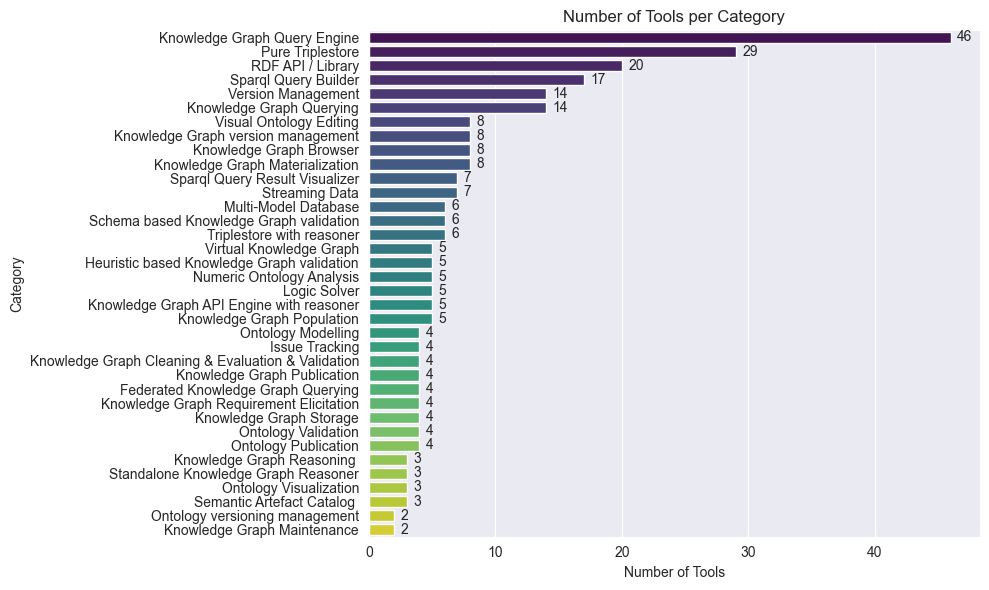

In [381]:
import matplotlib.pyplot as plt
import seaborn as sns

label_columns = [col for col in train_df.columns if col != "tool_description"]

    # Count samples per label
category_counts = train_df[label_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(y=category_counts.index, x=category_counts.values, palette="viridis" , hue = category_counts.index)


plt.title("Number of Tools per Category")
plt.xlabel("Number of Tools")
plt.ylabel("Category")

for i, v in enumerate(category_counts.values):
    ax.text(v + 0.5, i, str(v), va='center')


plt.tight_layout()
plt.savefig("category_count.png", dpi=300)
plt.show()

In [382]:
train_df = augment_minority_data(train_df, TEXT_COLUMN)

In [383]:
len(train_df)

1491

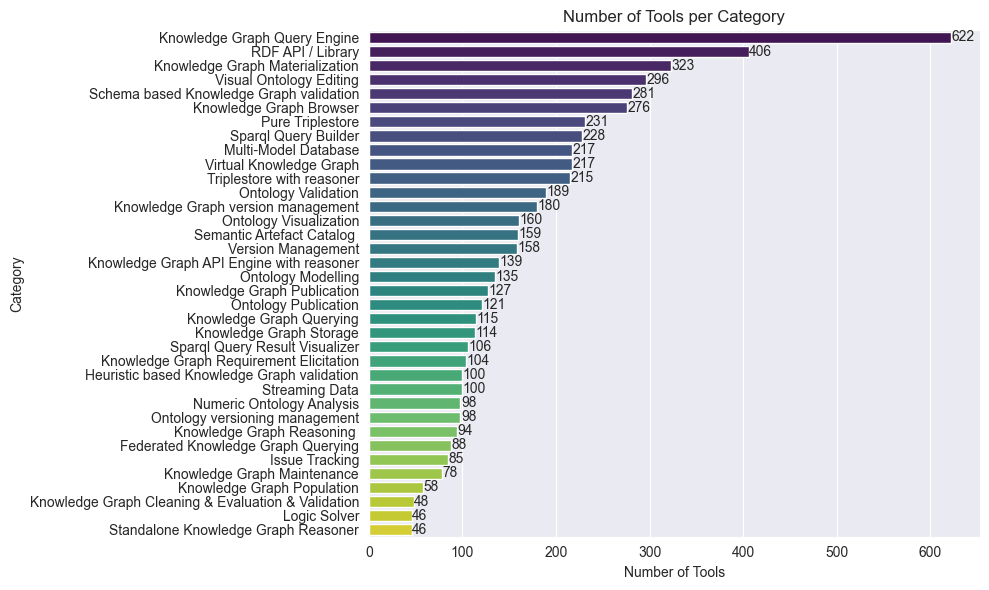

In [384]:
import matplotlib.pyplot as plt
import seaborn as sns

label_columns = [col for col in train_df.columns if col != "tool_description"]

    # Count samples per label
category_counts = train_df[label_columns].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(y=category_counts.index, x=category_counts.values, palette="viridis" , hue = category_counts.index)


plt.title("Number of Tools per Category")
plt.xlabel("Number of Tools")
plt.ylabel("Category")

for i, v in enumerate(category_counts.values):
    ax.text(v + 0.5, i, str(v), va='center')


plt.tight_layout()
plt.savefig("category_count.png", dpi=300)
plt.show()

#### Check Distribution of label categories

In [385]:
label_columns = [col for col in train_df.columns if col != "tool_description"]

train_category_counts = train_df[label_columns].sum().sort_values(ascending=False)
val_category_counts = val_df[label_columns].sum().sort_values(ascending=False)
test_category_counts = test_df[label_columns].sum().sort_values(ascending=False)

zero_in_train = (train_category_counts == 0).sum()
zero_in_val = (val_category_counts == 0).sum()
zero_in_test = (test_category_counts == 0).sum()


print(f"Number of Categories missing in training data: {zero_in_train}"
      f"\nNumber of Categories missing in validation data: {zero_in_val}"
      f"\nNumber of Categories missing in test data: {zero_in_test}")

Number of Categories missing in training data: 0
Number of Categories missing in validation data: 25
Number of Categories missing in test data: 28


In [386]:
train_loader = DataLoader(CustomDataset(train_df, tokenizer, MAX_SEQ_LENGTH), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(CustomDataset(val_df, tokenizer, MAX_SEQ_LENGTH),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(CustomDataset(test_df, tokenizer, MAX_SEQ_LENGTH),  batch_size=BATCH_SIZE, shuffle=False)

In [387]:
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 1491, Val: 15, Test: 15


### Model Training

In [388]:
from torch import nn

In [389]:
def load_checkpoint(checkpoint_path, model, optimizer):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    valid_loss_min = checkpoint["valid_loss_min"]
    return model, optimizer, checkpoint["epoch"], valid_loss_min.item()

def save_checkpoint(state, is_best, checkpoint_path, best_model_path):
    f_path = checkpoint_path
    torch.save(state, f_path)
    if is_best:
        best_fpath = best_model_path
        shutil.copyfile(f_path, best_fpath)

In [390]:
class BERT_Class(nn.Module):
    def __init__(self):
        super(BERT_Class, self).__init__()
        self.bert_model = BertModel.from_pretrained("bert-base-uncased" , return_dict=True)
        self.dropout = nn.Dropout(0.3)
        self.linear = nn.Linear(768,36)

    def forward(self , input_ids, attention_mask, token_type_ids):
        output = self.bert_model(input_ids, attention_mask, token_type_ids)
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)
        return output

In [391]:
model = BERT_Class()
model.to(DEVICE)

BERT_Class(
  (bert_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [392]:
def loss_func(outputs, targets):
    return nn.BCEWithLogitsLoss(pos_weight= pos_weight)(outputs, targets)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [393]:
from sklearn.metrics import f1_score, precision_score, recall_score

def compute_metrics(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred >= threshold).astype(int)
    return {
        f"Micro-F1: {f1_score(y_true, y_pred_bin, average="micro", zero_division=0):.4f} |Macro-F1: {f1_score(y_true, y_pred_bin, average="macro", zero_division=0):.4f} | Precision: {precision_score(y_true, y_pred_bin, average="micro", zero_division=0):.4f} | Recall: {recall_score(y_true, y_pred_bin, average="micro", zero_division=0):.4f}"
    }

In [394]:
from tqdm import tqdm

def train_model(
        n_epochs,
        train_dataloader,
        val_dataloader,
        model,
        optimizer,
        checkpoint_path,
        best_model_path
):
    valid_loss_min = np.inf

    for epoch in range(1, n_epochs+1):
        train_loss = 0
        val_loss = 0
        model.train()

        # training loop

        for index, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch: {epoch}")):
            input_ids = batch["input_ids"].to(DEVICE, dtype=torch.long)
            attention_mask = batch["attention_mask"].to(DEVICE, dtype=torch.long)
            token_type_ids = batch["token_type_ids"].to(DEVICE, dtype=torch.long)

            targets = batch["targets"].to(DEVICE, dtype=torch.float)
            outputs = model(input_ids, attention_mask, token_type_ids)

            optimizer.zero_grad()
            loss = loss_func(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss = train_loss + (1/(index+1) * (loss.item() - train_loss))

        # validation loop

        model.eval()

        all_preds = []
        all_targets = []

        with torch.no_grad():
            for index, batch in enumerate(val_dataloader):
                input_ids = batch["input_ids"].to(DEVICE, dtype=torch.long)
                attention_mask = batch["attention_mask"].to(DEVICE, dtype=torch.long)
                token_type_ids = batch["token_type_ids"].to(DEVICE, dtype=torch.long)

                targets = batch["targets"].to(DEVICE, dtype=torch.float)
                outputs = model(input_ids, attention_mask, token_type_ids)
                outputs = torch.sigmoid(outputs)

                loss = loss_func(outputs, targets)
                val_loss = val_loss + (1/(index+1)) * (loss.item() - val_loss)

                all_preds.append(outputs.cpu())
                all_targets.append(targets.cpu())

            y_pred = torch.cat(all_preds).numpy()
            y_true = torch.cat(all_targets).numpy()

            metrics = compute_metrics(y_true, y_pred)
            print(f"Validation Loss: {val_loss:.4f} | {metrics}")


        checkpoint = {
            'epoch': epoch+1,
            'valid_loss_min': val_loss,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
        }

        save_checkpoint(checkpoint, False, checkpoint_path, best_model_path)

    return model


In [395]:
trained_model = train_model(NUM_EPOCHS, train_loader, val_loader, model, optimizer, "checkpoints/current_checkpoint.pt", "best_model/best_model.pt")

Epoch: 1: 100%|██████████| 47/47 [03:18<00:00,  4.23s/it]


Validation Loss: 0.8174 | {'Micro-F1: 0.0000 |Macro-F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000'}


Epoch: 2: 100%|██████████| 47/47 [03:13<00:00,  4.11s/it]


Validation Loss: 0.7745 | {'Micro-F1: 0.0000 |Macro-F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000'}


Epoch: 3: 100%|██████████| 47/47 [03:14<00:00,  4.13s/it]


Validation Loss: 0.7578 | {'Micro-F1: 0.0952 |Macro-F1: 0.0278 | Precision: 0.2000 | Recall: 0.0625'}


### Evalutate Model performance after training on unseen data from test-set

In [396]:
def evaluate_model(model, dataloader):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for index, batch in enumerate(dataloader):
            input_ids = batch["input_ids"].to(DEVICE, dtype=torch.long)
            attention_mask = batch["attention_mask"].to(DEVICE, dtype=torch.long)
            token_type_ids = batch["token_type_ids"].to(DEVICE, dtype=torch.long)

            targets = batch["targets"].to(DEVICE, dtype=torch.float)
            outputs = model(input_ids, attention_mask, token_type_ids)
            outputs = torch.sigmoid(outputs)

            all_preds.append(outputs.cpu())
            all_targets.append(targets.cpu())

        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_targets).numpy()

    # Compute metrics
    metrics = compute_metrics(y_true, y_pred)

    return metrics

In [397]:
evaluate_model(trained_model, test_loader)

{'Micro-F1: 0.0000 |Macro-F1: 0.0000 | Precision: 0.0000 | Recall: 0.0000'}

In [398]:
target_list = ['Federated Knowledge Graph Querying',
       'Heuristic based Knowledge Graph validation', 'Issue Tracking',
       'Knowledge Graph API Engine with reasoner', 'Knowledge Graph Browser',
       'Knowledge Graph Cleaning & Evaluation & Validation',
       'Knowledge Graph Maintenance', 'Knowledge Graph Materialization',
       'Knowledge Graph Population', 'Knowledge Graph Publication',
       'Knowledge Graph Query Engine', 'Knowledge Graph Querying',
       'Knowledge Graph Reasoning ', 'Knowledge Graph Requirement Elicitation',
       'Knowledge Graph Storage', 'Knowledge Graph version management',
       'Logic Solver', 'Multi-Model Database', 'Numeric Ontology Analysis',
       'Ontology Modelling', 'Ontology Publication', 'Ontology Validation',
       'Ontology Visualization', 'Ontology versioning management',
       'Pure Triplestore', 'RDF API / Library',
       'Schema based Knowledge Graph validation', 'Semantic Artefact Catalog ',
       'Sparql Query Builder', 'Sparql Query Result Visualizer',
       'Standalone Knowledge Graph Reasoner', 'Streaming Data',
       'Triplestore with reasoner', 'Version Management',
       'Virtual Knowledge Graph', 'Visual Ontology Editing']

In [399]:
def predict(text, model, tokenizer, max_len, target_list, threshold=0.3):
    encodings = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        return_attention_mask=True,
        return_token_type_ids=True,
        truncation=True,
        return_tensors="pt"
    )
    model.eval()
    with torch.no_grad():
        input_ids = encodings["input_ids"].to(DEVICE, dtype=torch.long)
        attention_mask = encodings["attention_mask"].to(DEVICE, dtype=torch.long)
        token_type_ids = encodings["token_type_ids"].to(DEVICE, dtype=torch.long)
        outputs = model(input_ids, attention_mask, token_type_ids)
        final_outputs = torch.sigmoid(outputs).cpu().detach().numpy().tolist()
        print(final_outputs)

    all_predictions = []

    for probs in final_outputs:
        labels = [
            target_list[i]
            for i, prob in enumerate(probs)
            if prob >= threshold
        ]
        all_predictions.append(labels)

    return all_predictions

In [400]:
text = "A free, open-source ontology editor and framework for building intelligent systems. protege desktop protege is a free opensource ontology editor that supports the latest owl standard protege has a pluggable architecture and many plugins for different functionalities are available to read more about proteges features please visit the protege home page the latest version of protege can be downloaded from the protege website or from github if you would like to contribute to the protege project please see our contributing guide the developer documentation may be found on the wiki looking for support please ask questions on the protegeuser or protegedev mailing lists if you found a bug or would like to request a feature you may also use this issue tracker protege is released under the bsd clause license instructions for building from source are available on the the wiki Protege Desktop ['java', 'knowledge-graph', 'knowledge-management', 'obo', 'ontology', 'ontology-engineering', 'owl', 'protege', 'protege-desktop', 'rdf', 'reasoning', 'semantics'] Ontology editor"

predict(text, trained_model, tokenizer, max_len=128, target_list=target_list)

[[0.05113822594285011, 0.09680654108524323, 0.09090030193328857, 0.14328929781913757, 0.08402501046657562, 0.10580586642026901, 0.1934126615524292, 0.07704979926347733, 0.13201181590557098, 0.09752543270587921, 0.3057939410209656, 0.13778935372829437, 0.15243372321128845, 0.1332509070634842, 0.14694058895111084, 0.09890557080507278, 0.11234183609485626, 0.1121659129858017, 0.13524217903614044, 0.31568509340286255, 0.2803717255592346, 0.16064761579036713, 0.1218201294541359, 0.10186009109020233, 0.2209695726633072, 0.5240361094474792, 0.08970395475625992, 0.12190062552690506, 0.11347348242998123, 0.13122351467609406, 0.20163282752037048, 0.20912858843803406, 0.049996670335531235, 0.23459571599960327, 0.07181111723184586, 0.09253747761249542]]


[['Knowledge Graph Query Engine', 'Ontology Modelling', 'RDF API / Library']]